https://unit8co.github.io/darts/examples/13-TFT-examples.html
!pip uninstall -y coverage pytest-cov
!pip install "coverage>=7.4" "pytest-cov>=4.1"

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.datasets import AirPassengersDataset, IceCreamHeaterDataset
from darts.metrics import mape
from darts.models import TFTModel
from darts.utils.likelihood_models.torch import QuantileRegression
from darts.utils.statistics import check_seasonality, plot_acf
from darts.utils.timeseries_generation import datetime_attribute_timeseries

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

In [197]:
df = pd.read_csv("../data/processed/processed_data_pre_model.csv") 

# Cleaning columns
# Dropping lags, dupicate columns
df = df[['date'
                      , 'county_fips'
                      , 'county_name_x'
                      , 'median_listing_price_x' #taking median to control for outliers
                      , 'active_listing_count'
                      , 'median_days_on_market_x'
                      , 'new_listing_count'
                      , 'price_increased_count'
                      , 'price_increased_share'
                      , 'price_reduced_count'
                      , 'price_reduced_share'
                      , 'pending_listing_count'
                      #, 'median_listing_price_per_square_foot' #leaking target
                      , 'median_square_feet'
                      #, 'average_listing_price' #leaking target
                      , 'total_listing_count'
                      , 'pending_ratio'
                      , 'hotness_rank'
                      , 'hotness_score'
                      , 'supply_score'
                      , 'demand_score'
                      , 'median_dom_vs_us'
                      , 'page_view_count_per_property_vs_us'
                      #, 'median_listing_price_vs_us' #leaking target
                      , 'city'
                      , 'state'# how does this work, data quality?
                      , 'Earnings' # these are repeated?
                      , 'Unemployment_Rate' # these are repeated?
                      , 'Investor Purchases'
                      , 'Investor Market Share'
                      , 'U.S. 30 year FRM'
                      , '30 year fees & points'
                      , 'U.S. 15 year FRM'
                      , '15 year fees & points'
                      , 'U.S. 5/1 ARM'
                      , '5/1 year fees & points'
                      , 'U.S. 5/1 ARM margin'
                      , '30 year FRM / 5/1 ARM spread'
                      , 'highest_category' #Florida only
                      ]]

df.drop(columns=['hotness_rank' # dropping, rank and score are 100% correlated
, 'highest_category' #Florida only, dropping for now
, 'U.S. 15 year FRM' # dropping, highly correlated with 30 year 
, 'county_name_x' #county fips is numeric version
, 'city' # dupicative with fips
#,'state' # dupicative with fips
], inplace=True)

df = df.groupby(['state','date']).agg({
    'median_listing_price_x': 'mean',
    'active_listing_count': 'mean',
    'median_days_on_market_x': 'mean',
    'new_listing_count': 'mean',
    'price_increased_count': 'mean',
    'price_increased_share': 'mean',
    'price_reduced_count': 'mean',
    'price_reduced_share': 'mean',
    'pending_listing_count': 'mean',
    'median_square_feet': 'mean',
    'total_listing_count': 'mean',
    'pending_ratio': 'mean',
    'hotness_score': 'mean',
    'supply_score': 'mean',
    'demand_score': 'mean',
    'median_dom_vs_us': 'mean',
    'page_view_count_per_property_vs_us': 'mean',
    'Earnings': 'mean',
    'Unemployment_Rate': 'mean',
    'Investor Purchases': 'mean',
    'Investor Market Share': 'mean',
    'U.S. 30 year FRM': 'mean',
    '30 year fees & points': 'mean',
    'U.S. 5/1 ARM': 'mean',
    '5/1 year fees & points': 'mean',
    'U.S. 5/1 ARM margin': 'mean',
    '30 year FRM / 5/1 ARM spread': 'mean'
}).reset_index()

# Drop rows where median_listing_price_x is NA
df = df.dropna(subset=['median_listing_price_x'])

In [196]:
df_test = df.groupby('state')['Unemployment_Rate'].mean().reset_index()
df_test[df_test['state']=='ri']

,state,Unemployment_Rate
0,ri,NaN


In [155]:
# before starting, we define some constants
num_samples = 200

figsize = (9, 6)
lowest_q, low_q, high_q, highest_q = 0.01, 0.1, 0.9, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

## Notes
- need to validate why MAPE is nan
- need to run at total level also

In [194]:
df = df[df['state'].isin(['ri'])]

In [193]:
# Add lag and rolling features for the target (past-only, not known at forecast time)
lag_periods = [3,6,12]
rolling_windows = [3,6,12]

lag_cols = []
rolling_cols = []

for lag in lag_periods:
    col = f'median_listing_price_lag_{lag}'
    df[col] = df.groupby('state')['median_listing_price_x'].shift(lag)
    lag_cols.append(col)

for window in rolling_windows:
    col = f'median_listing_price_roll_{window}'
    df[col] = (
        df.groupby('state')['median_listing_price_x']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).mean())
    )
    rolling_cols.append(col)

engineered_cols = lag_cols + rolling_cols

# Drop rows with NaN introduced by lagging (first 12 months per state)
df = df.dropna(subset=engineered_cols)

In [192]:
df_state[all_cov_cols]

,U.S. 30 year FRM,Unemployment_Rate,Earnings,median_days_on_market_x,demand_score,supply_score,active_listing_count,pending_ratio,hotness_score,new_listing_count,median_listing_price_lag_3,median_listing_price_lag_6,median_listing_price_lag_12,median_listing_price_roll_3,median_listing_price_roll_6,median_listing_price_roll_12
4536,3.9675,NaN,NaN,53.2,90.000000,68.429752,738.8,0.31490,79.214876,335.2,418960.0,398377.0,396310.0,429953.266667,415828.733333,402354.366667
4537,3.8800,NaN,NaN,57.0,90.000000,68.429752,754.8,0.31244,79.214876,339.6,427564.8,400535.6,393220.0,435218.266667,421891.733333,405558.116667
4538,3.8050,NaN,NaN,60.4,84.573003,69.228650,752.2,0.66094,76.900826,282.4,443335.0,406200.0,382020.0,436455.000000,427014.966667,408729.366667
4539,3.8950,NaN,NaN,61.4,82.892562,73.388430,739.4,0.63472,78.140496,262.0,434755.0,418960.0,381520.0,432253.333333,431103.300000,412788.533333
4540,3.9220,NaN,NaN,66.4,80.165289,70.785124,698.4,0.60492,75.475207,211.6,431275.0,427564.8,388550.0,430532.533333,432875.400000,416794.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4635,6.2540,NaN,NaN,39.4,92.823691,88.898072,335.0,0.77676,90.860882,195.2,775640.0,721835.0,688910.0,771486.666667,758901.266667,720121.050000
4636,6.2375,NaN,NaN,43.2,92.286501,88.939394,314.2,0.84912,90.612948,144.0,763560.0,757480.0,678060.0,767060.000000,765655.433333,726241.883333
4637,6.1900,NaN,NaN,53.6,91.639118,86.914601,260.6,0.78886,89.276860,90.8,775260.0,759632.6,663845.0,758203.333333,762240.433333,731152.716667
4638,6.1025,NaN,NaN,61.8,92.245179,83.829201,232.0,0.80098,88.037190,112.0,762360.0,775640.0,677400.0,733718.333333,752602.500000,734316.050000


In [167]:
# Use Darts to predict median_listing_price_x with covariates for each state
results = {}

# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Loop over each state
for state, df_state in df.groupby('state'):
    df_state = df_state.sort_values('date')
    # Define future covariates (known ahead of time) and past covariates (only historical)
    future_cov_cols = ['U.S. 30 year FRM', 'Unemployment_Rate', 'Earnings']
    past_cov_cols = ['median_days_on_market_x', 'demand_score', 'supply_score', 'active_listing_count', 'pending_ratio', 'hotness_score', 'new_listing_count'] + engineered_cols
    all_cov_cols = future_cov_cols + past_cov_cols
    # Fill NaNs (forward-fill then back-fill to avoid gaps)
    df_state[all_cov_cols] = df_state[all_cov_cols].bfill().ffill()
    # Create target TimeSeries
    series = TimeSeries.from_dataframe(df_state, time_col='date', value_cols='median_listing_price_x', freq='MS')
    # Create future covariates TimeSeries (known at prediction time)
    future_covariates = TimeSeries.from_dataframe(df_state, time_col='date', value_cols=future_cov_cols, freq='MS')
    # Add time features to future covariates (year, month, trend are known ahead)
    future_covariates = future_covariates.stack(datetime_attribute_timeseries(series, attribute="year", one_hot=False))
    future_covariates = future_covariates.stack(datetime_attribute_timeseries(series, attribute="month", one_hot=False))
    future_covariates = future_covariates.stack(
        TimeSeries.from_times_and_values(
            times=series.time_index,
            values=np.arange(len(series)),
            columns=["linear_increase"],
        )
    )
    future_covariates = future_covariates.astype(np.float32)
    # Create past covariates TimeSeries (only historical values used)
    past_covariates = TimeSeries.from_dataframe(df_state, time_col='date', value_cols=past_cov_cols, freq='MS')
    past_covariates = past_covariates.astype(np.float32)
    # Set training cutoff
    training_cutoff = pd.Timestamp("2023-01-01")
    train, val = series.split_after(training_cutoff)
    # Normalize target
    transformer = Scaler()
    train_transformed = transformer.fit_transform(train)
    val_transformed = transformer.transform(val)
    series_transformed = transformer.transform(series)
    # Normalize future covariates
    scaler_future = Scaler()
    fut_train, fut_val = future_covariates.split_after(training_cutoff)
    scaler_future.fit(fut_train)
    future_covariates_transformed = scaler_future.transform(future_covariates)
    # Normalize past covariates
    scaler_past = Scaler()
    past_train, past_val = past_covariates.split_after(training_cutoff)
    scaler_past.fit(past_train)
    past_covariates_transformed = scaler_past.transform(past_covariates)
    # Store transformed series for each state
    results[state] = {
        'series_transformed': series_transformed,
        'train_transformed': train_transformed,
        'val_transformed': val_transformed,
        'future_covariates_transformed': future_covariates_transformed,
        'past_covariates_transformed': past_covariates_transformed,
        'train': train,
        'val': val
    }
# Now you can loop through results to fit a model for each state

# Fit a TFT model for each state and store the models and results
state_models = {}
state_metrics = {}

quantiles = [
    0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99,
]
input_chunk_length = 6
forecast_horizon = 12

for state, data in results.items():
    my_model = TFTModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=forecast_horizon,
        hidden_size=64,
        lstm_layers=2,
        num_attention_heads=4,
        dropout=0.3,
        batch_size=16,
        n_epochs=100,
        add_relative_index=False,
        add_encoders=None,
        likelihood=QuantileRegression(quantiles=quantiles),
        random_state=1,
    )
    my_model.fit(data['train_transformed'],
    future_covariates=data['future_covariates_transformed'],
    past_covariates=data['past_covariates_transformed'],
    val_series=data['val_transformed'],
    val_future_covariates=data['future_covariates_transformed'],
    val_past_covariates=data['past_covariates_transformed'],
    verbose=True,
                 )
    # Evaluate on validation set
    pred_series = my_model.predict(n=len(data['val_transformed']), future_covariates=data['future_covariates_transformed'], past_covariates=data['past_covariates_transformed'], num_samples=200)
    mape_score = mape(data['val_transformed'], pred_series)
    state_models[state] = my_model
    state_metrics[state] = mape_score
    print(f"State: {state}, MAPE: {mape_score:.2f}%")

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │      0 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 38.5 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │ 10.6 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │  1.1 K │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 323 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 323 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 527                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Output()

State: ri, MAPE: nan%


In [191]:
# --- DEBUGGING: Check validation and prediction for NaN MAPE ---
for state, data in results.items():
    print(f"State: {state}")
    print(f"  train_transformed length: {len(data['train_transformed'])}")
    print(f"  val_transformed length: {len(data['val_transformed'])}")
    print(f"  val_transformed head: {data['val_transformed'].head(3)}")
    print(f"  val_transformed tail: {data['val_transformed'].tail(3)}")
    # Fit model as before
    my_model = TFTModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=forecast_horizon,
        hidden_size=64,
        lstm_layers=1,
        num_attention_heads=4,
        dropout=0.1,
        batch_size=16,
        n_epochs=20,
        add_relative_index=False,
        add_encoders=None,
        likelihood=QuantileRegression(quantiles=quantiles),
        random_state=42,
    )
    my_model.fit(data['train_transformed'], future_covariates=data['covariates_transformed'], verbose=True)
    pred_series = my_model.predict(n=len(data['val_transformed']), future_covariates=data['covariates_transformed'], num_samples=200)
    print(f"  pred_series length: {len(pred_series)}")
    print(f"  pred_series head: {pred_series[:3]}")
    print(f"  pred_series tail: {pred_series[-3:]}")
    mape_score = mape(data['val_transformed'], pred_series)
    print(f"  MAPE: {mape_score}")
    state_models[state] = my_model
    state_metrics[state] = mape_score
    print("-")
# --- END DEBUG ---

State: ri
  train_transformed length: 67
  val_transformed length: 37
  val_transformed head:             median_listing_price_x
date                              
2023-02-01                1.092897
2023-03-01                1.355608
2023-04-01                1.289481

shape: (3, 1, 1), freq: MS, size: 24.00 B
  val_transformed tail:             median_listing_price_x
date                              
2025-12-01                1.494989
2026-01-01                1.531173
2026-02-01                1.622916

shape: (3, 1, 1), freq: MS, size: 24.00 B


KeyError: 'covariates_transformed'

Output()

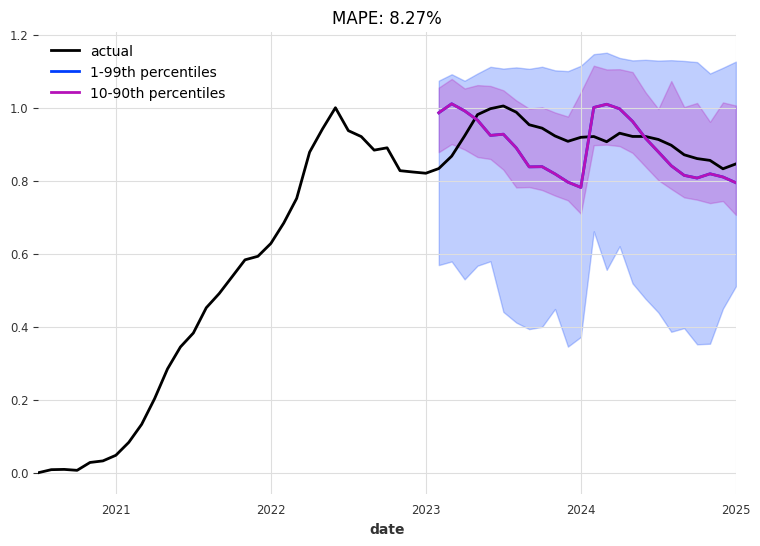

In [152]:
def eval_model(model, n, actual_series, val_series, state=None):
    pred_series = model.predict(n=n, num_samples=num_samples)
    plt.figure(figsize=figsize)
    actual_series[: pred_series.end_time()].plot(label="actual")
    pred_series.plot(low_quantile=lowest_q, high_quantile=highest_q, label=label_q_outer)
    pred_series.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
    title = f"MAPE: {mape(val_series, pred_series):.2f}%"
    if state is not None:
        title = f"{state} - " + title
    plt.title(title)
    plt.legend()

# Example usage for a specific state:
# eval_model(state_models['CA'], 24, results['CA']['series_transformed'], results['CA']['val_transformed'], state='CA')

eval_model(my_model, 24, series_transformed, val_transformed)

In [136]:
# Example: backtest for each state
state_backtests = {}
for state, model in state_models.items():
    data = results[state]
    backtest_series = model.historical_forecasts(
        data['series_transformed'],
        future_covariates=data['future_covariates_transformed'],
        past_covariates=data['past_covariates_transformed'],
        start=data['train'].end_time() + data['train'].freq,
        num_samples=num_samples,
        forecast_horizon=forecast_horizon,
        stride=forecast_horizon,
        last_points_only=False,
        retrain=False,
        verbose=True,
    )
    state_backtests[state] = backtest_series
# Now state_backtests[state] contains the backtest series for each state

Output()

Generating TimeSeries:   0%|          | 0/3 [00:00<?, ?it/s]

In [122]:
def eval_backtest(backtest_series, actual_series, horizon, start, transformer, state=None):
    plt.figure(figsize=figsize)
    actual_series.plot(label="actual")
    backtest_series.plot(
        low_quantile=lowest_q, high_quantile=highest_q, label=label_q_outer
    )
    backtest_series.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
    plt.legend()
    title = f"Backtest, starting {start}, {horizon}-months horizon"
    if state is not None:
        title = f"{state} - " + title
    plt.title(title)
    print(
        "MAPE: {:.2f}%".format(
            mape(
                transformer.inverse_transform(actual_series),
                transformer.inverse_transform(backtest_series),
            )
        )
    )

# Example usage for a specific state:
# eval_backtest(
#     backtest_series=concatenate(state_backtests['CA']),
#     actual_series=results['CA']['series_transformed'],
#     horizon=forecast_horizon,
#     start=results['CA']['train'].end_time() + results['CA']['train'].freq,
#     transformer=results['CA']['transformer'],
#     state='CA'
# )

In [ ]:
# Save the by-state models in a pickle file
import pickle

with open('../data/processed/state_models.pkl', 'wb') as f:
    pickle.dump(state_models, f)

print('By-state models saved to ../data/processed/state_models.pkl')